# Гистограммы

In [ ]:
import numpy as np
import random
import sympy
import math
import matplotlib.pyplot as plt

In [ ]:
matrix_p=np.array([[0.45, 0.4, 0.15],
                  [0, 0.45, 0.55],
                  [0, 0.0, 1]])
matrix_p_inin=np.array([0.8, 0.2, 0])
matrix_p_inin=[(0,0.8),(0.8,1),(0,0)]




[[0.45 0.4  0.15]
 [0.   0.45 0.55]
 [0.   0.   1.  ]]


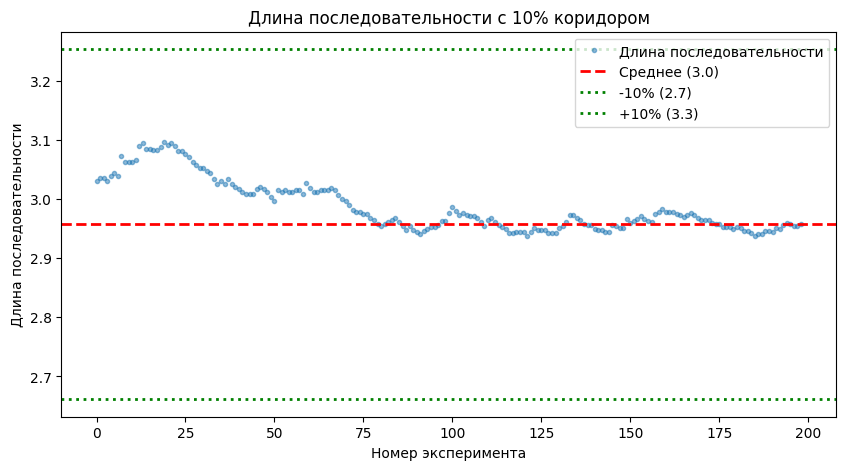

In [32]:
matrix_p=np.array([[0.45, 0.4, 0.15],
                  [0, 0.45, 0.55],
                  [0, 0.0, 1]])
matrix_p_inin=np.array([0.8, 0.2, 0])
matrix_p_inin=[(0,0.8),(0.8,1),(0,0)]
def test():
    otvet=[]
    index_s=0
    rval=random.uniform(0,1)
    for i in matrix_p_inin:
        if i[0]<=rval<i[1]:
            index_s=matrix_p_inin.index(i)            
        else:
            continue
    while(True):
        rval=random.uniform(0,1)
        pred=0
        for i in matrix_p[index_s]:
            new_pred=pred+i
            if pred<=rval<new_pred:
                index_s=list(matrix_p[index_s]).index(i)
                otvet.append(index_s)
                break
            else:
                pred=new_pred
                continue
        if index_s==2:
            break
    return otvet
# round(sum([len(test()) for _ in range(1000)])/1000)
# print(round(sum([len(test()) for _ in range(1000)])/1000,1))
# Запуск тестов и вычисление статистики
num_trials = 200
lengths = [len(test()) for i in range(1,num_trials)]
mean_lengths=[]
for i in range(1,num_trials):
    lengths.append(len(test()))
    mean_lengths.append(sum(lengths) / len(lengths))
mean_length=mean_lengths[-1]
# Определение границ коридора
lower_bound = mean_length * 0.9
upper_bound = mean_length * 1.1

# Построение графика
plt.figure(figsize=(10, 5))
plt.plot(mean_lengths, marker='.', linestyle='', alpha=0.5, label="Длина последовательности")
plt.axhline(mean_length, color='red', linestyle='dashed', linewidth=2, label=f"Среднее ({mean_length:.1f})")
plt.axhline(lower_bound, color='green', linestyle='dotted', linewidth=2, label=f"-10% ({lower_bound:.1f})")
plt.axhline(upper_bound, color='green', linestyle='dotted', linewidth=2, label=f"+10% ({upper_bound:.1f})")

plt.xlabel("Номер эксперимента")
plt.ylabel("Длина последовательности")
plt.title("Длина последовательности с 10% коридором")
plt.legend()
plt.show()

{'[3, 0]': 86.758, '[3, 1]': 12.026, '[0, 3]': 0.01, '[1, 3]': 0.03, '[3, 2]': 1.114, '[2, 3]': 0.062}


C:\Users\anton\AppData\Local\Temp\ipykernel_17832\1621312847.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(dict_otvet.keys())


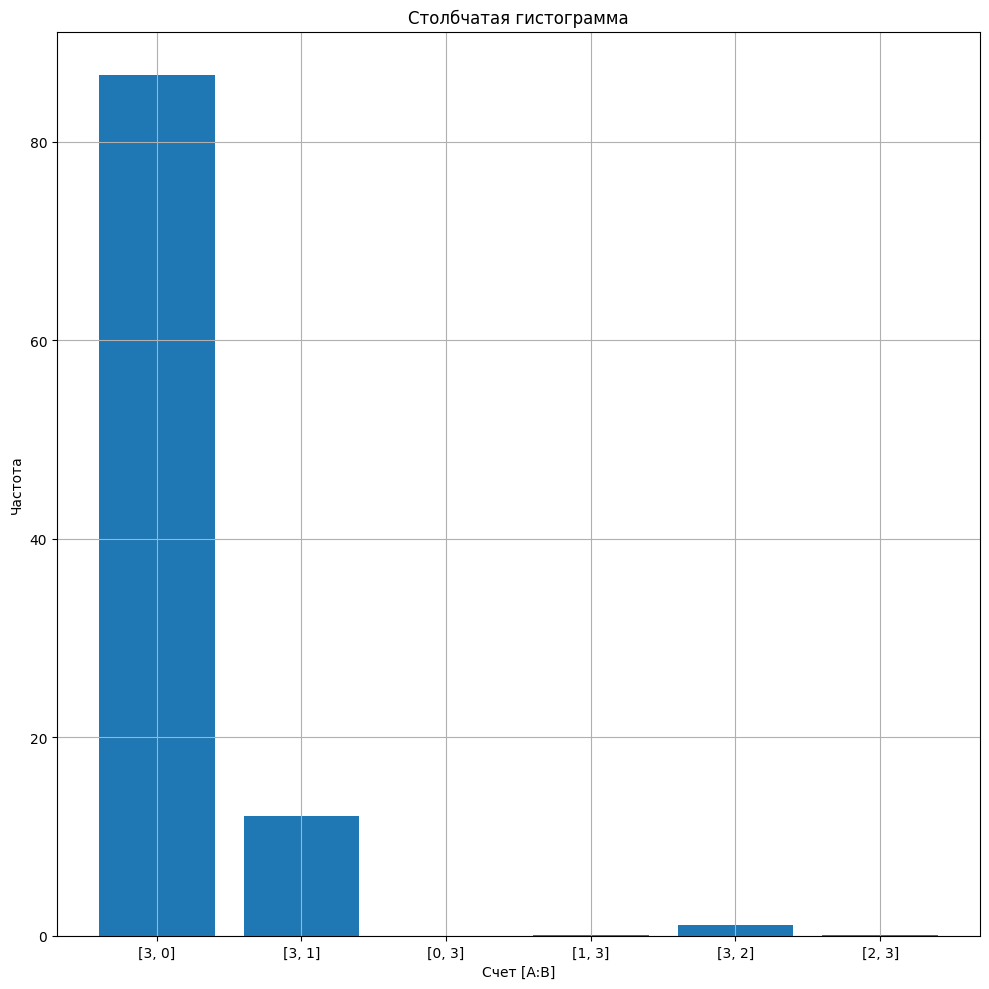

In [16]:
matrix_p_g=[[0.7, 0.3],[0.6, 0.4]]
def game(start=0,end_game=15,otvet1=[0,0]):
    otvet=otvet1
    index_s=start
    start+=1
    store=[0,0]  
    while(True):
        rval=random.uniform(0,1)
        pred=0
        for i in matrix_p_g[index_s]:
            new_pred=pred+i
            if pred<=rval<new_pred:
                index_s=matrix_p_g[index_s].index(i)
                store[index_s]+=1
                break
            else:
                pred=new_pred
                continue
        if (store[0]>=end_game or store[1]>=end_game):
            if store[0]>=end_game:
                otvet[0]+=1
            else:
                otvet[1]+=1
            break
    if otvet[0]>=3 or otvet[1]>=3:
        return otvet
    game(start=start%2,otvet1=otvet)
    
    return otvet

set_g=[game(0,15,[0,0])]
for i in range(1,100000):
    set_g.append(game(0,15,[0,0]))
dict_otvet={
    "[3, 0]":0,
    "[3, 1]":0,
    "[0, 3]":0,
    "[1, 3]":0,
    "[3, 2]":0,
    "[2, 3]":0
}
for i in set_g:
    key=f'{i}'
    dict_otvet[key]+=1

for i in dict_otvet.keys():
    dict_otvet[i]/=1000
print(dict_otvet)
x_pos = np.arange(len(dict_otvet))  # Позиции столбцов на оси X

# Создаем фигуру с двумя subplots (один над другим)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

# Нижний график - столбчатая гистограмма
axes.bar(dict_otvet.keys(), dict_otvet.values(), width=0.8, align='center')

axes.set_xticklabels(dict_otvet.keys())
axes.set_xlabel("Cчет [A:B]")
axes.set_ylabel("Частота")
axes.set_title("Столбчатая гистограмма")
axes.grid(True)

# Настраиваем расстояние между графиками
plt.tight_layout()
plt.show()